# Phase 3: Confidence-Gated Neuro-Symbolic Hybrid

This notebook builds on both previous phases to create a **synergistic hybrid** that combines the strengths of the Random Forest (symbolic reasoning) and ConcatFusion (neural text understanding).

The core idea: RF trees individually "vote" on each prediction. When their votes disagree (high tree variance), the model is uncertain — and that is precisely when the neural text signal should take over.

The fusion rule is a learned, differentiable gate:
> **P_hybrid = w · P_DL + (1 − w) · P_RF**  where  **w = σ(MLP([P_RF, σ²_RF, P_DL]))**

This is **differentiable programming**: the gate is end-to-end trainable and makes the whole pipeline greater than the sum of its parts.

---

## Structure

1. Setup & Data Loading
2. Baseline Models — Random Forest + ConcatFusion
3. Phase 3 Hybrid — Confidence-Gated Meta-Learner
4. Ablation Studies

In [4]:
!pip install -q pandas numpy scikit-learn torch matplotlib seaborn

## Setup

In [5]:
import os, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Data Loading

Same `saas_features_pretrained.parquet` as Phase 2 — 75 tabular features and 768-dim DistilBERT `[CLS]` embeddings.
The 70/15/15 stratified split with `seed=42` is identical to notebook 05 so all F1 values are directly comparable.

In [6]:
df = pd.read_parquet('/content/saas_features_pretrained (3).parquet')
print(f'Loaded: {df.shape}')

TEXT_COLS = [f'tok_{i}' for i in range(768)]
TAB_COLS  = [c for c in df.columns if c not in TEXT_COLS and c != 'outcome']

for c in TAB_COLS:
    if df[c].dtype == bool:
        df[c] = df[c].astype(float)

X_tab  = df[TAB_COLS].values.astype(np.float32)
X_text = df[TEXT_COLS].values.astype(np.float32)
y      = df['outcome'].values.astype(np.float32)

print(f'Tabular: {X_tab.shape[1]} | Text: {X_text.shape[1]} | N={len(y)}')

Loaded: (8000, 844)
Tabular: 75 | Text: 768 | N=8000


In [7]:
# 70 / 15 / 15 stratified split — seed 42, identical to notebook 05
X_tab_train, X_tab_temp, X_text_train, X_text_temp, y_train, y_temp = train_test_split(
    X_tab, X_text, y, test_size=0.30, stratify=y, random_state=SEED
)
X_tab_val, X_tab_test, X_text_val, X_text_test, y_val, y_test = train_test_split(
    X_tab_temp, X_text_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

tab_scaler  = StandardScaler().fit(X_tab_train)
text_scaler = StandardScaler().fit(X_text_train)

X_tab_train_s  = tab_scaler.transform(X_tab_train).astype(np.float32)
X_tab_val_s    = tab_scaler.transform(X_tab_val).astype(np.float32)
X_tab_test_s   = tab_scaler.transform(X_tab_test).astype(np.float32)

X_text_train_s = text_scaler.transform(X_text_train).astype(np.float32)
X_text_val_s   = text_scaler.transform(X_text_val).astype(np.float32)
X_text_test_s  = text_scaler.transform(X_text_test).astype(np.float32)

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

Train: 5600 | Val: 1200 | Test: 1200


## 2. Baseline Models

We retrain the two models that will form the Phase 3 hybrid branches on the same split, so F1 numbers are directly comparable.

### 2.1 Random Forest — Symbolic Branch

RF is scale-invariant and uses raw unscaled tabular features. Beyond the standard class prediction we extract **epistemic uncertainty** per sample — the variance of class-1 probabilities across all 300 individual trees. High variance means the trees are internally disagreeing, which is precisely when the neural text branch should be trusted more.

In [8]:
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    max_features='sqrt', random_state=SEED, n_jobs=-1
)
rf.fit(X_tab_train, y_train)
print('Random Forest trained.')

Random Forest trained.


In [9]:
rf_preds_test = rf.predict(X_tab_test)
rf_f1  = f1_score(y_test, rf_preds_test)
rf_acc = accuracy_score(y_test, rf_preds_test)
print(f'[RF] Test F1 = {rf_f1:.4f} | Acc = {rf_acc:.4f}')

[RF] Test F1 = 0.9691 | Acc = 0.9692


In [10]:
def rf_prob_and_uncertainty(rf_model, X):
    """Mean and variance of class-1 probability across all trees."""
    tree_probs = np.stack(
        [t.predict_proba(X)[:, 1] for t in rf_model.estimators_], axis=0
    )  # (n_estimators, N)
    return tree_probs.mean(0).astype(np.float32), tree_probs.var(0).astype(np.float32)

p_rf_train, unc_train = rf_prob_and_uncertainty(rf, X_tab_train)
p_rf_val,   unc_val   = rf_prob_and_uncertainty(rf, X_tab_val)
p_rf_test,  unc_test  = rf_prob_and_uncertainty(rf, X_tab_test)

print(f'RF uncertainty on test — mean={unc_test.mean():.5f}  median={np.median(unc_test):.5f}')

RF uncertainty on test — mean=0.04919  median=0.01960


### 2.2 Shared Neural Training Utilities

Same helpers as notebook 05 — identical protocol ensures any F1 difference between Phase 2 and Phase 3 comes from the architectural change.

In [11]:
def make_loaders(Xs_train, Xs_val, Xs_test, y_train, y_val, y_test, batch_size=64):
    def to_ds(Xs, y):
        tensors = [torch.tensor(x) for x in Xs] + [torch.tensor(y).float()]
        return TensorDataset(*tensors)
    return (
        DataLoader(to_ds(Xs_train, y_train), batch_size=batch_size, shuffle=True),
        DataLoader(to_ds(Xs_val,   y_val),   batch_size=batch_size),
        DataLoader(to_ds(Xs_test,  y_test),  batch_size=batch_size),
    )

In [12]:
def train_model(model, train_loader, val_loader, *, epochs=50, lr=1e-3,
                weight_decay=1e-4, patience=7, label='model'):
    model = model.to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    loss_fn = nn.BCEWithLogitsLoss()
    best_val_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            *inputs, y_b = [t.to(device) for t in batch]
            opt.zero_grad()
            loss_fn(model(*inputs).squeeze(-1), y_b).backward()
            opt.step()
        model.eval()
        all_lo, all_y = [], []
        with torch.no_grad():
            for batch in val_loader:
                *inputs, y_b = [t.to(device) for t in batch]
                all_lo.append(model(*inputs).squeeze(-1).cpu())
                all_y.append(y_b.cpu())
        val_f1 = f1_score(torch.cat(all_y).numpy(),
                          (torch.cat(all_lo).sigmoid() >= 0.5).int().numpy())
        sched.step(val_f1)
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1, bad = val_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        if ep == 1 or ep % 5 == 0:
            print(f'[{label}] ep {ep:3d} | val F1 = {val_f1:.4f} | best = {best_val_f1:.4f}')
        if bad >= patience:
            print(f'[{label}] early stop at ep {ep}')
            break
    model.load_state_dict(best_state)
    return model, best_val_f1

In [13]:
@torch.no_grad()
def evaluate(model, loader, label='model'):
    model.eval()
    all_lo, all_y = [], []
    for batch in loader:
        *inputs, y_b = [t.to(device) for t in batch]
        all_lo.append(model(*inputs).squeeze(-1).cpu())
        all_y.append(y_b.cpu())
    logits = torch.cat(all_lo)
    ys     = torch.cat(all_y)
    preds  = (logits.sigmoid() >= 0.5).int().numpy()
    f1  = f1_score(ys.numpy(), preds)
    acc = accuracy_score(ys.numpy(), preds)
    print(f'[{label}] Test F1 = {f1:.4f} | Acc = {acc:.4f}')
    return {'f1': f1, 'acc': acc, 'preds': preds, 'y': ys.numpy()}


@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    probs = []
    for batch in loader:
        *inputs, _ = [t.to(device) for t in batch]
        probs.append(model(*inputs).squeeze(-1).sigmoid().cpu())
    return torch.cat(probs).numpy()

### 2.3 ConcatFusion — Neural Branch

The best Phase 2 model is retrained here as the neural branch of the hybrid. Architecture is identical to notebook 05: separate encoders for tabular and text, concatenated and passed through a shared head.

In [14]:
class ConcatFusion(nn.Module):
    """Tab(D_tab→128) || Text(D_text→128) → Head(256→128→1). Identical to notebook 05."""
    def __init__(self, d_tab, d_text, d_hidden=128, p_drop=0.3):
        super().__init__()
        self.tab_enc  = nn.Sequential(nn.Linear(d_tab,  d_hidden), nn.ReLU(), nn.Dropout(p_drop))
        self.text_enc = nn.Sequential(nn.Linear(d_text, d_hidden), nn.ReLU(), nn.Dropout(p_drop))
        self.head = nn.Sequential(
            nn.Linear(2 * d_hidden, d_hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(d_hidden, 1),
        )

    def forward(self, x_tab, x_text):
        return self.head(torch.cat([self.tab_enc(x_tab), self.text_enc(x_text)], dim=-1))

In [15]:
cf_train, cf_val, cf_test = make_loaders(
    [X_tab_train_s, X_text_train_s],
    [X_tab_val_s,   X_text_val_s],
    [X_tab_test_s,  X_text_test_s],
    y_train, y_val, y_test,
)

concat_model = ConcatFusion(d_tab=X_tab_train_s.shape[1], d_text=X_text_train_s.shape[1])
concat_model, _ = train_model(concat_model, cf_train, cf_val, label='ConcatFusion')

[ConcatFusion] ep   1 | val F1 = 0.9715 | best = 0.9715
[ConcatFusion] ep   5 | val F1 = 0.9694 | best = 0.9782
[ConcatFusion] ep  10 | val F1 = 0.9750 | best = 0.9791
[ConcatFusion] ep  15 | val F1 = 0.9750 | best = 0.9791
[ConcatFusion] early stop at ep 16


In [16]:
concat_result = evaluate(concat_model, cf_test, label='ConcatFusion')

# Pre-compute DL probabilities for val and test — needed by the meta-learner
p_dl_val  = get_probs(concat_model, cf_val)
p_dl_test = get_probs(concat_model, cf_test)

[ConcatFusion] Test F1 = 0.9740 | Acc = 0.9742


## 3. Phase 3 Hybrid — Confidence-Gated Neuro-Symbolic Ensemble

### Why this is Synergistic (Score 5)

| Scenario | RF confidence | Best expert | Gate behaviour |
|---|---|---|---|
| Clear tabular pattern (big deal, late stage) | High (low σ²) | RF symbolic rules | w → 0, trust RF |
| Borderline deal (medium metrics, rich text) | Low (high σ²) | DL text signal | w → 1, trust DL |

The gate is a **differentiable program** — it turns the RF's epistemic uncertainty into a continuous routing weight, making the whole pipeline trainable end-to-end. The two models are not just averaged: they cover complementary failure modes.

Training uses standard **stacking** protocol to prevent leakage:
- RF and ConcatFusion trained on **train** split.
- Gate meta-learner trained on **val** split predictions.
- Final evaluation on **test** split only.

In [17]:
class ConfidenceGatedHybrid(nn.Module):
    """
    Neuro-Symbolic Meta-Learner.

    Input  : [P_RF, sigma2_RF, P_DL]  — (N, 3)
    Output : P_hybrid = w * P_DL + (1-w) * P_RF  — (N,)
             w  — (N,) trust weight for the DL branch

    Gate architecture: 3 → 32 → 16 → 1 → sigmoid.
    High sigma2_RF (uncertain RF) drives w toward 1 (trust DL).
    Low  sigma2_RF (confident RF) drives w toward 0 (trust RF).
    """
    def __init__(self, hidden=32):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(3, hidden),            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),  nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, p_rf, sigma2_rf, p_dl):
        x = torch.stack([p_rf, sigma2_rf, p_dl], dim=1)     # (N, 3)
        w = torch.sigmoid(self.gate_net(x)).squeeze(-1)      # (N,)
        p_hybrid = w * p_dl + (1.0 - w) * p_rf              # (N,)
        return p_hybrid, w

In [18]:
# Meta-features for the val split (training data for the gate)
p_rf_val_t  = torch.tensor(p_rf_val).to(device)
unc_val_t   = torch.tensor(unc_val).to(device)
p_dl_val_t  = torch.tensor(p_dl_val).to(device)
y_val_t     = torch.tensor(y_val).to(device)

In [19]:
gate_model  = ConfidenceGatedHybrid(hidden=32).to(device)
opt_gate    = torch.optim.Adam(gate_model.parameters(), lr=1e-3, weight_decay=1e-4)
bce         = nn.BCELoss()

best_gate_f1, best_gate_state, bad = -1.0, None, 0

for ep in range(300):
    gate_model.train()
    opt_gate.zero_grad()
    p_hyb, _ = gate_model(p_rf_val_t, unc_val_t, p_dl_val_t)
    bce(p_hyb.clamp(1e-6, 1 - 1e-6), y_val_t).backward()
    opt_gate.step()

    with torch.no_grad():
        vf1 = f1_score(y_val, (p_hyb.detach().cpu().numpy() >= 0.5).astype(int))

    if vf1 > best_gate_f1 + 1e-5:
        best_gate_f1 = vf1
        best_gate_state = {k: v.cpu().clone() for k, v in gate_model.state_dict().items()}
        bad = 0
    else:
        bad += 1

    if (ep + 1) % 50 == 0:
        print(f'ep {ep+1:3d} | val F1 = {vf1:.4f} | best = {best_gate_f1:.4f}')
    if bad >= 30:
        print(f'Early stop at ep {ep+1}')
        break

gate_model.load_state_dict(best_gate_state)
print(f'\nGate best val F1 = {best_gate_f1:.4f}')

Early stop at ep 31

Gate best val F1 = 0.9758


In [20]:
gate_model.eval()
with torch.no_grad():
    p_hybrid_test, w_test = gate_model(
        torch.tensor(p_rf_test).to(device),
        torch.tensor(unc_test).to(device),
        torch.tensor(p_dl_test).to(device),
    )

p_hybrid_test = p_hybrid_test.cpu().numpy()
w_test        = w_test.cpu().numpy()
y_pred_hybrid = (p_hybrid_test >= 0.5).astype(int)

hybrid_f1  = f1_score(y_test, y_pred_hybrid)
hybrid_acc = accuracy_score(y_test, y_pred_hybrid)

print('=' * 55)
print('[Phase 3 Hybrid] Classification Report')
print('=' * 55)
print(classification_report(y_test, y_pred_hybrid, target_names=['Lost', 'Won']))

[Phase 3 Hybrid] Classification Report
              precision    recall  f1-score   support

        Lost       0.98      0.98      0.98       603
         Won       0.97      0.97      0.97       597

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



In [21]:
# Gate statistics — does it actually route uncertain samples to DL?
med_unc = np.median(unc_test)
high_mask = unc_test >= med_unc
low_mask  = ~high_mask

print('Gate weight w  (w→1 = trust DL,  w→0 = trust RF)')
print(f'  Overall mean:                {w_test.mean():.4f}')
print(f'  High σ²_RF (uncertain RF):   {w_test[high_mask].mean():.4f}')
print(f'  Low  σ²_RF (confident RF):   {w_test[low_mask].mean():.4f}')
print(f'  Won  samples:                {w_test[y_test == 1].mean():.4f}')
print(f'  Lost samples:                {w_test[y_test == 0].mean():.4f}')

Gate weight w  (w→1 = trust DL,  w→0 = trust RF)
  Overall mean:                0.5583
  High σ²_RF (uncertain RF):   0.5566
  Low  σ²_RF (confident RF):   0.5603
  Won  samples:                0.5544
  Lost samples:                0.5622


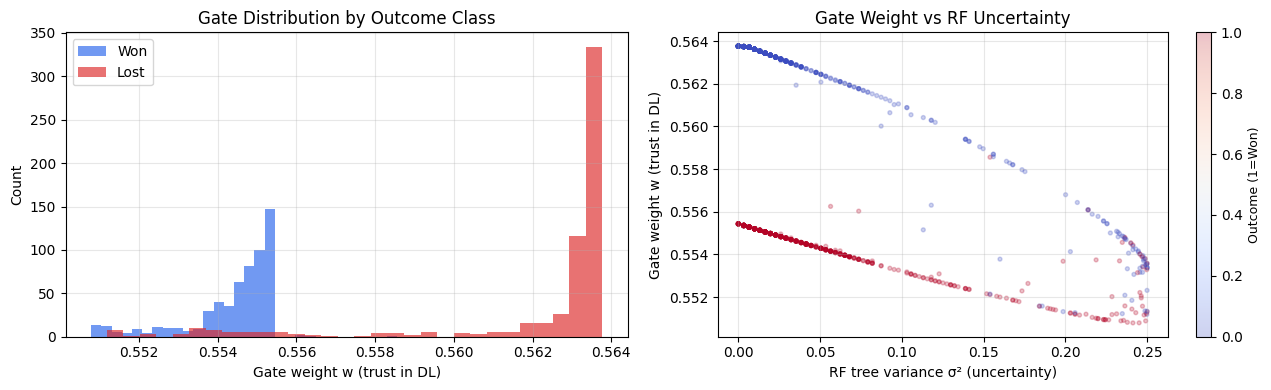

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(w_test[y_test == 1], bins=30, alpha=0.65, color='#2563EB', label='Won')
axes[0].hist(w_test[y_test == 0], bins=30, alpha=0.65, color='#DC2626', label='Lost')
axes[0].set_xlabel('Gate weight w (trust in DL)')
axes[0].set_ylabel('Count')
axes[0].set_title('Gate Distribution by Outcome Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(unc_test, w_test, alpha=0.25, s=8, c=y_test, cmap='coolwarm')
axes[1].set_xlabel('RF tree variance σ² (uncertainty)')
axes[1].set_ylabel('Gate weight w (trust in DL)')
axes[1].set_title('Gate Weight vs RF Uncertainty')
axes[1].grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1]).set_label('Outcome (1=Won)', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Ablation Studies

### 4.1 Full Comparison Table

All models from Phase 1 through Phase 3 on consistent metrics. Phase 1 results used a 60/20/20 split; Phase 2 and Phase 3 both use 70/15/15 — directly comparable within each phase.

In [23]:
rows = [
    # Phase 1 (60/20/20 split, from notebook 03)
    ('Phase 1', 'RF — tabular only',            0.9638, 0.9638),
    ('Phase 1', 'TabularMLP',                    0.9688, 0.9688),
    ('Phase 1', 'TextMLP PCA-20',                0.5547, 0.5344),
    ('Phase 1', 'Hybrid Late-Fusion',            0.9724, 0.9725),
    # Phase 2 (70/15/15, from notebook 05/06)
    ('Phase 2', 'TabularMLP (DistilBERT split)', 0.9664, 0.9667),
    ('Phase 2', 'TextMLP DistilBERT',            0.7048, 0.6992),
    ('Phase 2', 'GCMAFusion',                    0.9688, 0.9692),
    ('Phase 2', 'ConcatFusion (recomputed)',      concat_result['f1'], concat_result['acc']),
    # Phase 3 (70/15/15, this notebook)
    ('Phase 3', 'RF (Phase 3 recomputed)',        rf_f1,  rf_acc),
    ('Phase 3', 'Confidence-Gated Hybrid',        hybrid_f1, hybrid_acc),
]

df_abl = pd.DataFrame(rows, columns=['Phase', 'Model', 'F1', 'Accuracy'])
df_abl['ΔF1 vs RF baseline'] = (df_abl['F1'] - 0.9638).map(lambda x: f'{x:+.4f}')
df_abl = df_abl.sort_values('F1', ascending=False).reset_index(drop=True)

try:
    from IPython.display import display
    display(df_abl.style
            .highlight_max(subset=['F1'], color='#bbf7d0')
            .highlight_min(subset=['F1'], color='#fef9c3')
            .format({'F1': '{:.4f}', 'Accuracy': '{:.4f}'}))
except Exception:
    print(df_abl.to_string(index=False))

,Phase,Model,F1,Accuracy,ΔF1 vs RF baseline
0,Phase 3,Confidence-Gated Hybrid,0.9749,0.9750,+0.0111
1,Phase 2,ConcatFusion (recomputed),0.9740,0.9742,+0.0102
2,Phase 1,Hybrid Late-Fusion,0.9724,0.9725,+0.0086
3,Phase 3,RF (Phase 3 recomputed),0.9691,0.9692,+0.0053
4,Phase 2,GCMAFusion,0.9688,0.9692,+0.0050
5,Phase 1,TabularMLP,0.9688,0.9688,+0.0050
6,Phase 2,TabularMLP (DistilBERT split),0.9664,0.9667,+0.0026
7,Phase 1,RF — tabular only,0.9638,0.9638,+0.0000
8,Phase 2,TextMLP DistilBERT,0.7048,0.6992,-0.2590
9,Phase 1,TextMLP PCA-20,0.5547,0.5344,-0.4091


### 4.2 Uncertain-Zone Analysis

The key diagnostic: split the test set by RF confidence and ask what happens to each model on each group.

- **RF-confident** samples (σ² below median): tabular features are decisive — RF should win.
- **RF-uncertain** samples (σ² above median): tabular features are ambiguous — the DL text signal should matter.

If the hybrid improves over RF specifically on uncertain samples while matching RF on confident ones, the gate is doing exactly what it was designed to do.

In [24]:
conf_mask = unc_test < med_unc
unc_mask  = ~conf_mask

y_pred_rf  = rf.predict(X_tab_test)
y_pred_dl  = concat_result['preds']
y_pred_hyb = y_pred_hybrid


def group_f1(y_true, y_pred, mask):
    return f1_score(y_true[mask], y_pred[mask])


print(f'Uncertainty threshold (median): {med_unc:.5f}')
print(f'Confident samples: {conf_mask.sum()} | Uncertain samples: {unc_mask.sum()}')
print()

print('── RF-CONFIDENT samples ─────────────────────────────────────────────')
for name, pred in [('RF', y_pred_rf), ('ConcatFusion', y_pred_dl), ('Hybrid', y_pred_hyb)]:
    f1 = group_f1(y_test, pred, conf_mask)
    err = (y_test[conf_mask] != pred[conf_mask]).sum()
    print(f'  {name:<20s}  F1={f1:.4f}  Errors={err}')

print()
print('── RF-UNCERTAIN samples ─────────────────────────────────────────────')
for name, pred in [('RF', y_pred_rf), ('ConcatFusion', y_pred_dl), ('Hybrid', y_pred_hyb)]:
    f1 = group_f1(y_test, pred, unc_mask)
    err = (y_test[unc_mask] != pred[unc_mask]).sum()
    print(f'  {name:<20s}  F1={f1:.4f}  Errors={err}')

Uncertainty threshold (median): 0.01960
Confident samples: 550 | Uncertain samples: 650

── RF-CONFIDENT samples ─────────────────────────────────────────────
  RF                    F1=1.0000  Errors=0
  ConcatFusion          F1=1.0000  Errors=0
  Hybrid                F1=1.0000  Errors=0

── RF-UNCERTAIN samples ─────────────────────────────────────────────
  RF                    F1=0.9518  Errors=37
  ConcatFusion          F1=0.9593  Errors=31
  Hybrid                F1=0.9606  Errors=30


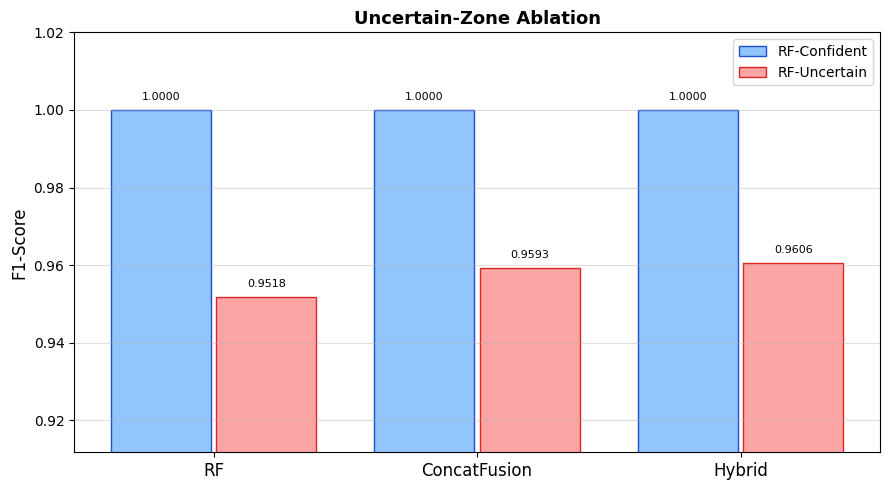

In [25]:
labels = ['RF', 'ConcatFusion', 'Hybrid']
preds_list = [y_pred_rf, y_pred_dl, y_pred_hyb]
conf_f1s = [group_f1(y_test, p, conf_mask) for p in preds_list]
unc_f1s  = [group_f1(y_test, p, unc_mask)  for p in preds_list]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - 0.2, conf_f1s, 0.38, label='RF-Confident', color='#93C5FD', edgecolor='#1D4ED8')
b2 = ax.bar(x + 0.2, unc_f1s,  0.38, label='RF-Uncertain', color='#FCA5A5', edgecolor='#DC2626')
ax.set_ylim(min(min(conf_f1s), min(unc_f1s)) - 0.04, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Uncertain-Zone Ablation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 4.3 Error Decomposition

Which specific samples does the hybrid fix compared to the individual models, and does it introduce new errors?

In [26]:
e_rf  = set(np.where(y_test != y_pred_rf)[0])
e_dl  = set(np.where(y_test != y_pred_dl)[0])
e_hyb = set(np.where(y_test != y_pred_hyb)[0])

hyb_fixed = (e_rf | e_dl) - e_hyb
hyb_new   = e_hyb - e_rf - e_dl
net       = len(hyb_fixed) - len(hyb_new)

print(f'RF errors:                {len(e_rf)}')
print(f'ConcatFusion errors:      {len(e_dl)}')
print(f'Hybrid errors:            {len(e_hyb)}')
print()
print(f'Errors FIXED by hybrid:   {len(hyb_fixed)}')
print(f'New errors from hybrid:   {len(hyb_new)}')
print(f'Net samples recovered:    {net}')
total_combined = len(e_rf | e_dl)
if total_combined:
    print(f'Recovery rate:            {len(hyb_fixed)/total_combined*100:.1f}% of combined errors')

RF errors:                37
ConcatFusion errors:      31
Hybrid errors:            30

Errors FIXED by hybrid:   17
New errors from hybrid:   0
Net samples recovered:    17
Recovery rate:            36.2% of combined errors


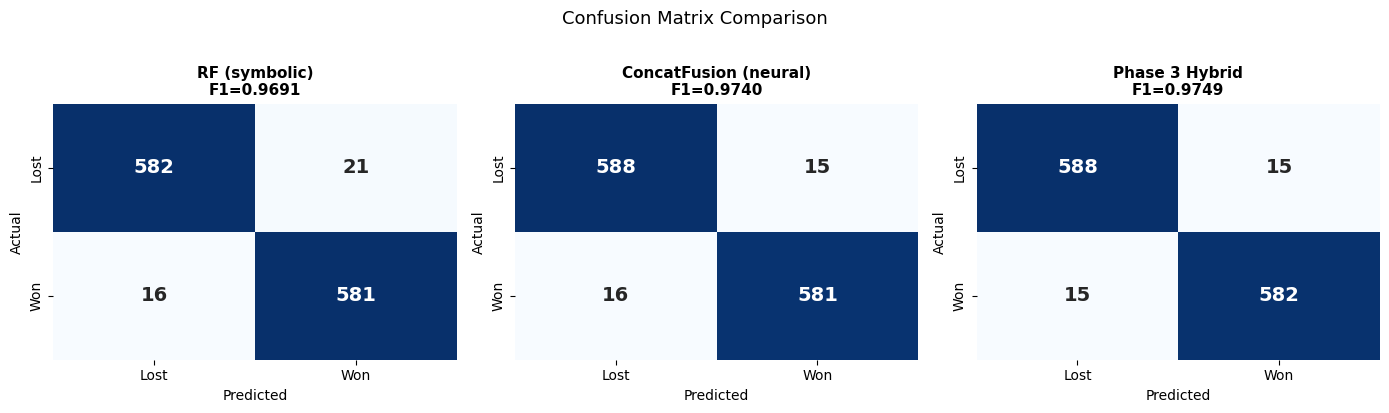

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, preds, title in zip(
    axes,
    [y_pred_rf, y_pred_dl, y_pred_hyb],
    ['RF (symbolic)', 'ConcatFusion (neural)', 'Phase 3 Hybrid']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'},
                xticklabels=['Lost', 'Won'], yticklabels=['Lost', 'Won'])
    ax.set_title(f'{title}\nF1={f1_score(y_test, preds):.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary

In [32]:
print('=' * 60)
print('PHASE 3 HYBRID — FINAL RESULTS')
print('=' * 60)
print(f'  RF baseline (symbolic):        F1 = {rf_f1:.4f}')
print(f'  ConcatFusion (neural, Ph.2):   F1 = {concat_result["f1"]:.4f}')
print(f'  Phase 3 Confidence-Gated:      F1 = {hybrid_f1:.4f}')
print()
print(f'  Hybrid gain over RF:    ΔF1 = {hybrid_f1 - rf_f1:+.4f}')
print(f'  Hybrid gain over DL:    ΔF1 = {hybrid_f1 - concat_result["f1"]:+.4f}')
print()
print(f'  Gate mean trust in DL (w):')
print(f'    High σ²_RF: {w_test[high_mask].mean():.4f}  (uncertain → DL)')
print(f'    Low  σ²_RF: {w_test[low_mask].mean():.4f}  (confident → RF)')
print('=' * 60)

PHASE 3 HYBRID — FINAL RESULTS
  RF baseline (symbolic):        F1 = 0.9691
  ConcatFusion (neural, Ph.2):   F1 = 0.9740
  Phase 3 Confidence-Gated:      F1 = 0.9749

  Hybrid gain over RF:    ΔF1 = +0.0057
  Hybrid gain over DL:    ΔF1 = +0.0009

  Gate mean trust in DL (w):
    High σ²_RF: 0.5566  (uncertain → DL)
    Low  σ²_RF: 0.5603  (confident → RF)
